In [ ]:
# YOLOv8 Training for E. coli Detection
# This notebook is designed to run on Google Colab with GPU
# Data should be uploaded to Google Drive as YOLOv8_data.zip

# Mount Google Drive and copy data
from google.colab import drive
drive.mount('/content/drive')

!cp -r /content/drive/MyDrive/YOLOv8_data.zip /content

In [2]:
#Unzip YOLOv8 data
import os
import zipfile
zip_path = '/content/YOLOv8_data.zip'
extract_path = '/content/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [10]:
!rm rf /content/runs/detect

rm: cannot remove 'rf': No such file or directory
rm: cannot remove '/content/runs/detect': Is a directory


In [ ]:
!pip install ultralytics

In [6]:
#Import YOLO
from ultralytics import YOLO
#Create a Function for Training
def train_model(name, a=[0.5,0.2,0.015,0.7,0.4,0.5,0.5], batch_size=64, optimizer='AdamW', lr = 0.0013, epochs = 200, imgsz=608, model_path='yolov8n.pt', data='YOLOv8_data/original_data.yaml'):
  model = YOLO(model_path)
  results = model.train(
      optimizer=optimizer, lr0=lr, data=data, epochs=epochs,
      imgsz=imgsz, batch=batch_size, name=name,
      mosaic=a[0], mixup=a[1], hsv_h=a[2],
      hsv_s=a[3], hsv_v=a[4], flipud=a[5], fliplr=a[6],
      device='cuda', pretrained=True, augment=True, patience=200, seed=42)
  return model

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Compare between Rotation(Existing) Augmentation vs Best Augmentation

1. Rotation(Existing) Augmentation YOLOv8 SGD
2. Strong Augmentation YOLOv8 SGD
3. Rotation(Existing) Augmentation YOLOv8 AdamW
4. Strong Augmentation YOLOv8 AdamW

In [ ]:
#Train Model of SGD with Existing Augmentation (Same Parameter Same Augmentation as Existing Work using YOLOv8)
model = train_model(name='SGDa3', a=[1.0,0.1,0.1,1.0,1.0,0.5,0.0], lr=0.0013, imgsz=608,
            optimizer='SGD', epochs=200, data='YOLOv8_data/augment_dataset3.yaml')
model.val()

In [ ]:
#Train Model of SGD with our Augmentation
model = train_model(name='SGDa2', a=[1.0,0.1,0.1,1.0,1.0,0.5,0.0], lr=0.0013, imgsz=608,
            optimizer='SGD', epochs=200, data='YOLOv8_data/augment_dataset2.yaml')
model.val()

In [ ]:
#Train Model with AdamW with Existing Augmentation
model = train_model(name='AdamWa3', a=[0.5,0.2,0.015,0.7,0.4,0.5,0.5], lr=0.03, imgsz=640,
            optimizer='AdamW', epochs=200, data='YOLOv8_data/augment_dataset3.yaml')
model.val()

In [ ]:
#Train Model of AdamW with our Augmentation + Higher Batches (Best Result so Far)
model = train_model(name='AdamWa2', a=[0.5,0.2,0.015,0.7,0.4,0.5,0.5], lr=0.03, imgsz=640,
            optimizer='AdamW', epochs=200, data='YOLOv8_data/augment_dataset2..yaml')
model.val()

In [23]:
def compare_result(df1, df2, label1, label2):
    plt.figure(figsize=(12, 6))
    plt.subplot(221)
    plt.plot(df1['metrics/mAP50(B)'][0:200], label=label1+'-mAP50')
    plt.plot(df2['metrics/mAP50(B)'][0:200], label=label2+'-mAP50')
    plt.yticks([.1,.2,.3,.4,.5,.6,.7,.8,.9,1])
    plt.title('mAP50')
    plt.legend()

    plt.subplot(222)
    plt.plot(df1['metrics/mAP50-95(B)'][0:200], label=label1+'-mAP50-95')
    plt.plot(df2['metrics/mAP50-95(B)'][0:200], label=label2+'-mAP50-95')
    plt.yticks([.1,.2,.3,.4,.5,.6,.7,.8,.9,1])
    plt.title('mAP50-95')
    plt.legend()

    plt.subplot(223)
    plt.plot(df1['metrics/recall(B)'][0:200], label=label1+'-Recall')
    plt.plot(df2['metrics/recall(B)'][0:200], label=label2+'-Recall')
    plt.yticks([.1,.2,.3,.4,.5,.6,.7,.8,.9,1])
    plt.title('Recall')
    plt.legend()

    plt.subplot(224)
    plt.plot(df1['metrics/precision(B)'][0:200], label=label1+'-Precision')
    plt.plot(df2['metrics/precision(B)'][0:200], label=label2+'-Precision')
    plt.yticks([.1,.2,.3,.4,.5,.6,.7,.8,.9,1])
    plt.title('Precision')
    plt.legend()

    plt.plot()


In [36]:
def compute_stats(df1, df2, label1, label2):
  print(label1 + " Best mAP50: " + str(max(df1['metrics/mAP50(B)'][0:200])))
  print(label2 + " Best mAP50: " + str(max(df2['metrics/mAP50(B)'][0:200])))
  print(label1 + " Best mAP50-95: " + str(max(df1['metrics/mAP50-95(B)'][0:200])))
  print(label2 + " Best mAP50-95: " + str(max(df2['metrics/mAP50-95(B)'][0:200])))
  print(label1 + " Best Recall: " + str(max(df1['metrics/recall(B)'][0:200])))
  print(label2 + " Best Recall: " + str(max(df2['metrics/recall(B)'][0:200])))
  print(label1 + " Best Precision: " + str(max(df1['metrics/precision(B)'][0:200])))
  print(label2 + " Best Precision: " + str(max(df2['metrics/precision(B)'][0:200])))

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
AdamW_StrongAug = pd.read_csv('/content/runs/AdamW_Strong_Aug/results.csv')
AdamW_WeakAug = pd.read_csv('/content/runs/AdamW_Weak_Aug/results.csv')
SGD_StrongAug = pd.read_csv('/content/runs/SGD_Strong_Aug/results.csv')
SGD_WeakAug = pd.read_csv('/content/runs/SGD_Weak_Aug/results.csv')

AdamW Strong Aug Best mAP50: 0.95232
AdamW Weak Aug Best mAP50: 0.93726
AdamW Strong Aug Best mAP50-95: 0.77837
AdamW Weak Aug Best mAP50-95: 0.37198
AdamW Strong Aug Best Recall: 0.92058
AdamW Weak Aug Best Recall: 0.91483
AdamW Strong Aug Best Precision: 0.93419
AdamW Weak Aug Best Precision: 0.92704


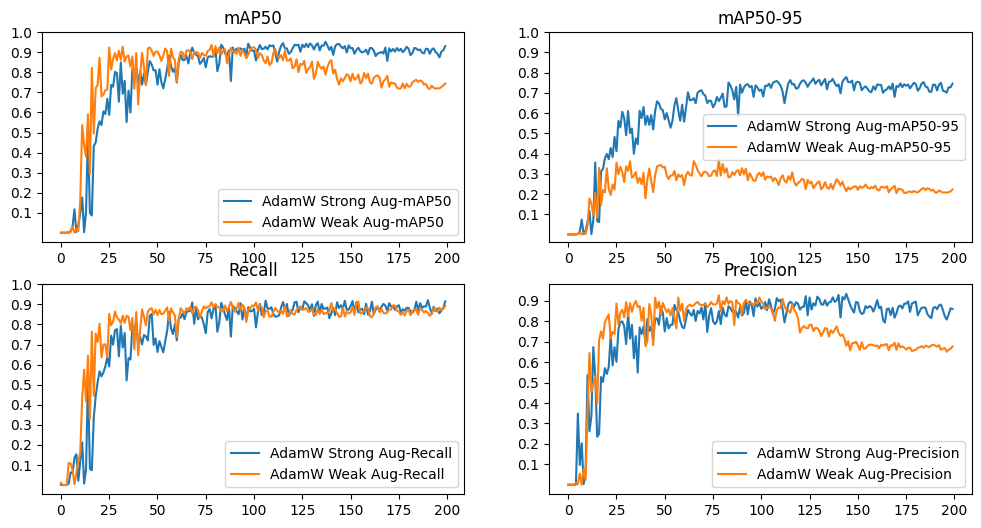

In [37]:
compare_result(AdamW_StrongAug, AdamW_WeakAug, 'AdamW Strong Aug', 'AdamW Weak Aug')
compute_stats(AdamW_StrongAug, AdamW_WeakAug, 'AdamW Strong Aug', 'AdamW Weak Aug')

SGD Strong Aug Best mAP50: 0.9241
SGD Weak Aug Best mAP50: 0.92193
SGD Strong Aug Best mAP50-95: 0.76897
SGD Weak Aug Best mAP50-95: 0.3534
SGD Strong Aug Best Recall: 0.9395
SGD Weak Aug Best Recall: 0.92528
SGD Strong Aug Best Precision: 0.89769
SGD Weak Aug Best Precision: 0.9146


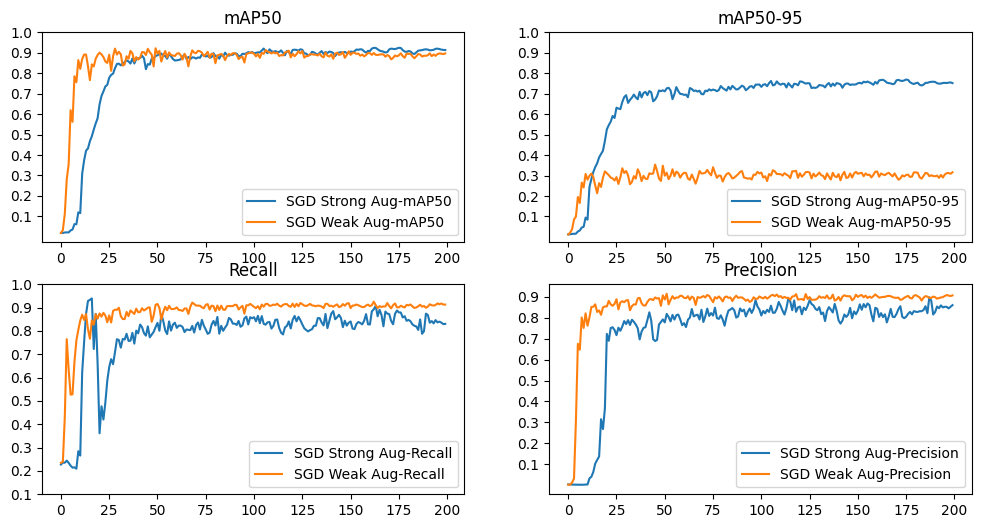

In [38]:
compare_result(SGD_StrongAug, SGD_WeakAug, 'SGD Strong Aug', 'SGD Weak Aug')
compute_stats(SGD_StrongAug, SGD_WeakAug, 'SGD Strong Aug', 'SGD Weak Aug')

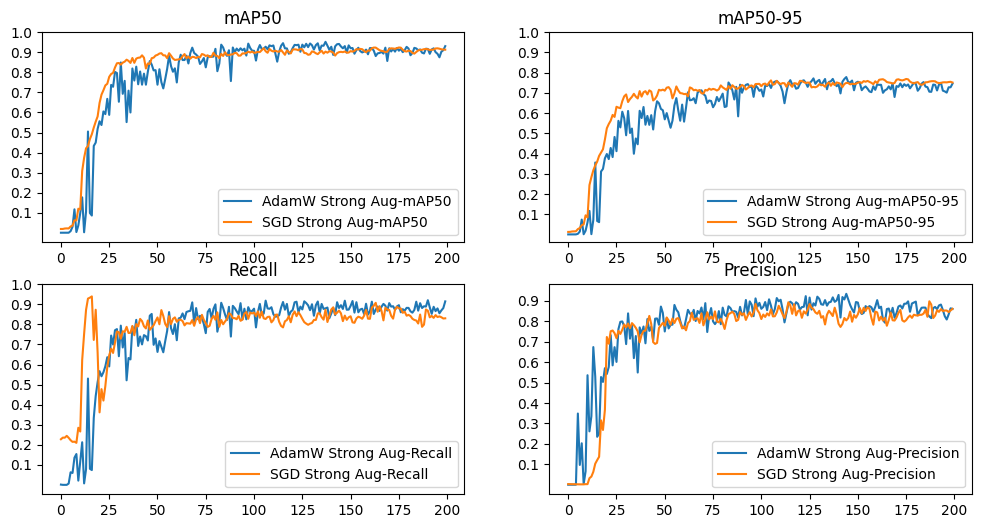

In [27]:
compare_result(AdamW_StrongAug, SGD_StrongAug, 'AdamW Strong Aug', 'SGD Strong Aug')